# Task 1: Comparative Analysis of Dimensional Measurement Systems

---

This section evaluates the performance and capability of two manual measurement instruments: the Digital Micrometer and the Vernier Micrometer.The primary objective is to analyze dimensional data to determine system effectiveness in terms of resolution and repeatability.

---

##  Objectives & Scope
This analysis is structured to fulfill the specific requirements of Task 1 as outlined in the MN5610 assessment brief:

* **`Capability Assessment`**: Evaluating the measurement system's performance by quantifying Resolution and Repeatability based on the data collected by two operators.

* **`Statistical Validation`**: Executing a Two-way ANOVA supplemented by Manual Calculations to identify significant trends and source variations between operators and instruments.

* **`Operational Procedure & Uncertainty`**: Detailing the standard procedure for micrometer usage and investigating factors that contribute to measurement uncertainty, such as environmental temperature ($20 \pm 1^\circ C$) and human influence.

* **`Minimization & Control`**: Proposing strategies to minimize or control identified uncertainty contributors to ensure data integrity and traceability.

* **`Instrument Appraisal`**: Providing a formal appraisal of the suitability of both Digital and Vernier micrometers for small-batch inspections against specified component tolerances.

---

##  Technical Specifications
The measurement of the **measurand** (cylinder diameter) followed these experimental parameters:

| Feature | Description |
| :--- | :--- |
| **Measurand** | External Diameter of a Cylinder  |
| **Instruments** | Digital Micrometer vs. Vernier Micrometer  |
| **Operators** | Two Operators (10 repetitions each)  |
| **Environment** | Controlled Metrology Laboratory ($20 \pm 1^\circ C$)  |
| **Total Samples** | 40 Observations |

---

##  Analytical Methodology
The quantitative evaluation is implemented through a structured statistical workflow:

1.  **`Data Preprocessing`**: Converting raw experimental data into a long-format structure for robust modeling.

2.  **`Assumption Verification`**:

    * **Normality**: Testing residuals using Shapiro-Wilk and Q-Q Plots to ensure a Gaussian distribution.

    * **Homogeneity**: Checking for equal variance across groups using **Levene’s Test**.

    * **Outlier Detection**: Boxplots are implemented to identify any extreme values (outliers) that could potentially skew the statistical mean and influence the results.

3.  **`Variance Analysis`**: Executing Two-way ANOVA to extract $F$-statistics and $p$-values for operator and instrument effects.

4.  **`Visual Interpretation`**: Utilizing Interaction Plots to visualize trends and measurement stability.

---



# STEP 1: Data Ingestion & Preprocessing

In [53]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1.1 Read Excel File
df_raw = pd.read_excel('cylineder_measurements.xlsx')


# 1.2 change column names to reflect the actual data (since columns 2 and 3 are the measurements)
df_raw.columns = ['Operator', 'Digital', 'Vernier']

# 1.3 Transform Wide -> Long Format using pd.melt()
df = pd.melt(df_raw, 
             id_vars=['Operator'],               # Keep the Operator column as is
             value_vars=['Digital', 'Vernier'],  # Capture the two measurement columns
             var_name='Instrument',              # Set the name of the new column for instrument type
             value_name='Measurement')           # Set the name of the new column for measurement values

print("--- Data Preview  ---")
print(df.head())
print(f"\n row count: {len(df)} \n")

--- Data Preview  ---
  Operator Instrument  Measurement
0      Op1    Digital    22.214000
1      Op1    Digital    22.212000
2      Op1    Digital    22.211000
3      Op1    Digital    22.211000
4      Op1    Digital    22.210000

 row count: 40 



## STEP 2: Assumption Checks

In [40]:
# ==========================================
# STEP 2: Assumption Checks
# ==========================================

# Create  Model to get Residuals (Error Terms)
model = ols('Measurement ~ C(Operator) * C(Instrument)', data=df).fit()
residuals = model.resid

print("--- Assumption Checks ---")
# 2.1 Normality Test (Shapiro-Wilk)
shapiro_test = stats.shapiro(residuals)
print(f"1. Shapiro-Wilk Test: W={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

# 2.2 Homogeneity of Variance (Levene's Test)
dig = df[df['Instrument'] == 'Digital']['Measurement']
ver = df[df['Instrument'] == 'Vernier']['Measurement']
levene_test = stats.levene(dig, ver)
print(f"2. Levene's Test: W={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4f}\n")


--- Assumption Checks ---
1. Shapiro-Wilk Test: W=0.9524, p-value=0.0920
2. Levene's Test: W=3.0116, p-value=0.0908



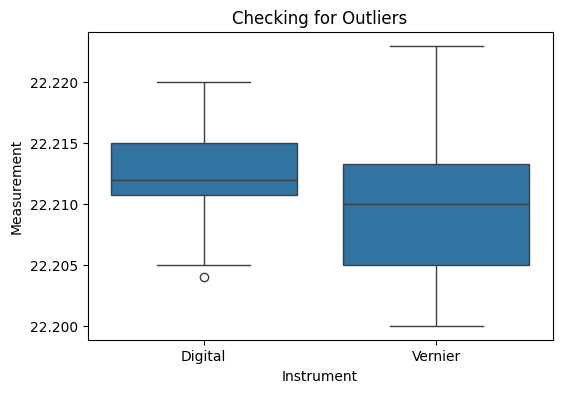

Count of Digital: 20
Count of Vernier: 20


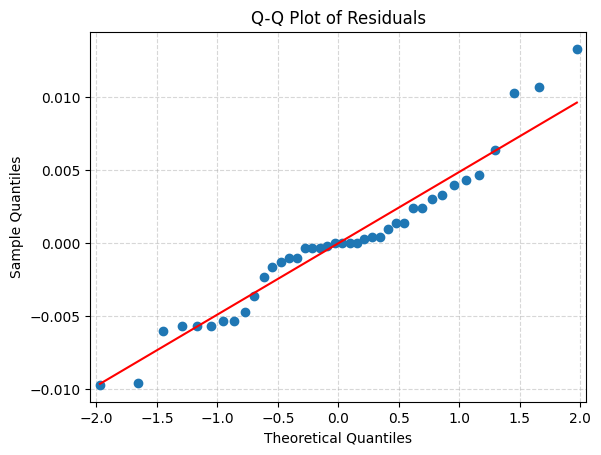

In [59]:
#  Boxplot to visually check for outliers
plt.figure(figsize=(6,4))
sns.boxplot(x='Instrument', y='Measurement', data=df)
plt.title("Checking for Outliers")
plt.show()

print("Count of Digital:", len(dig))
print("Count of Vernier:", len(ver))

#  Q-Q Plot for Normality 
fig1 = sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

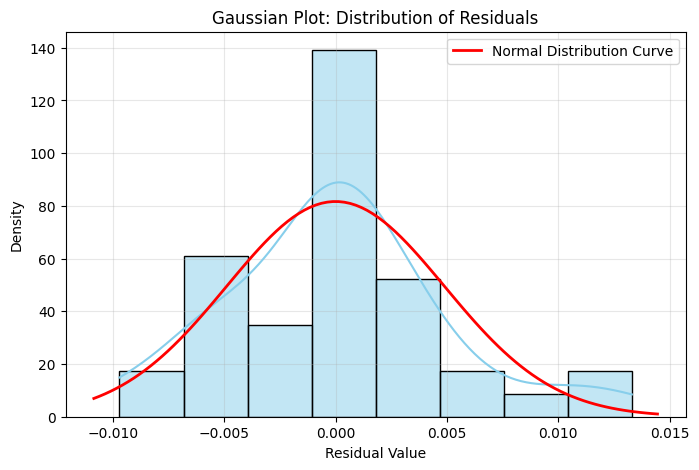

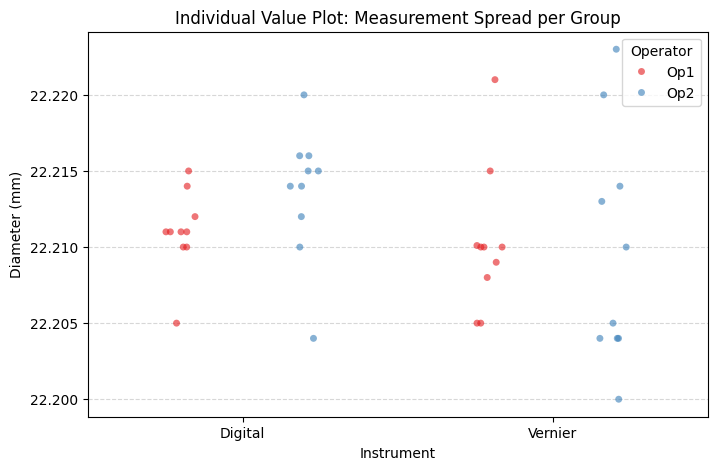

In [57]:
#  Gaussian Plot (Normality Visualization)
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='skyblue', stat="density")
# Add reference Normal Distribution line
mu, std = stats.norm.fit(residuals)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution Curve')
plt.title("Gaussian Plot: Distribution of Residuals")
plt.xlabel("Residual Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#  Individual Value Plot 
plt.figure(figsize=(8, 5))
sns.stripplot(x='Instrument', y='Measurement', hue='Operator', data=df, 
              dodge=True, alpha=0.6, jitter=True, palette='Set1')
plt.title("Individual Value Plot: Measurement Spread per Group")
plt.ylabel("Diameter (mm)")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

## STEP 3: ANOVA Results

In [48]:
# --- STEP 3: ANOVA Results (Formatted) ---
anova_table = sm.stats.anova_lm(model, typ=2)

# format the ANOVA table to 6 decimal places for better readability
formatted_anova = anova_table.copy()
pd.options.display.float_format = '{:.6f}'.format

print("--- FINAL ANOVA TABLE ---")
display(formatted_anova)

--- FINAL ANOVA TABLE ---


,sum_sq,df,F,PR(>F)
C(Operator),0.000010,1.000000,0.373379,0.545007
C(Instrument),0.000053,1.000000,1.986413,0.167297
C(Operator):C(Instrument),0.000026,1.000000,0.971526,0.330879
Residual,0.000955,36.000000,NaN,NaN


# STEP 4: Visualization for  Interaction

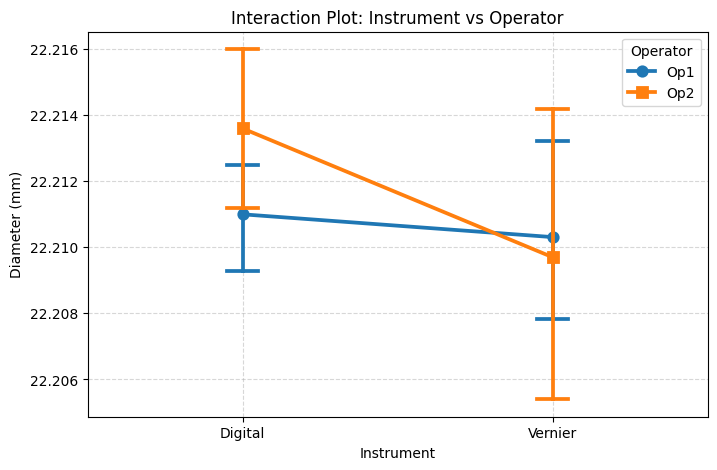

In [58]:
#  Interaction Plot
plt.figure(figsize=(8, 5))
sns.pointplot(x='Instrument', y='Measurement', hue='Operator', data=df, capsize=.1, markers=['o', 's'])
plt.title("Interaction Plot: Instrument vs Operator")
plt.ylabel("Diameter (mm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##  Task 3: Statistical Process Control (SPC) & Predictive Maintenance
---

**Conceptual Overview:**
This section focuses on the transition from reactive to proactive quality control. By monitoring the Total Indicator Reading (TIR) of torque shafts over a series of samples, we implement a Statistical Process Control (SPC) framework.

* `Objective`: To detect "Process Drift"—such as tool wear or thermal expansion—before the components exceed the critical 28μm tolerance limit.
* `Logic`: The script utilizes conditional logic to automatically color-code the data points (Green for Pass, Red for Fail), providing immediate visual feedback for shop-floor decision-making and maintenance scheduling.

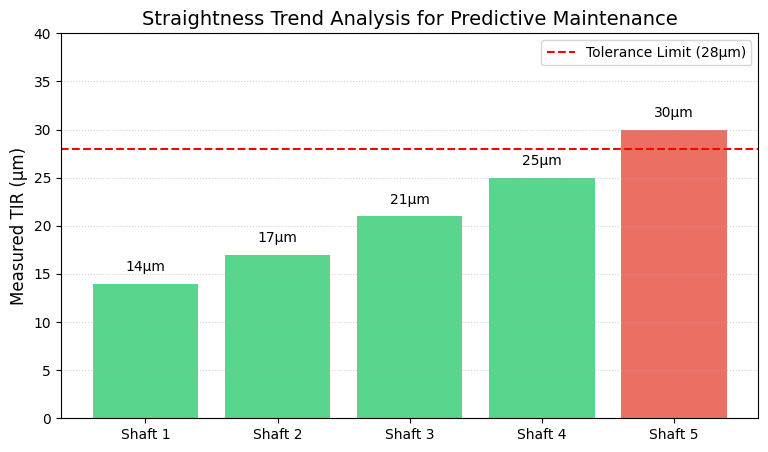

In [63]:
import matplotlib.pyplot as plt

# Representative TIR data for 5 Torque Shafts (in micrometers)
# This data simulates a trend of increasing deviation
shafts = ['Shaft 1', 'Shaft 2', 'Shaft 3', 'Shaft 4', 'Shaft 5']
tir_values = [14, 17, 21, 25, 30]  # Simulated measurements
tolerance_limit = 28  # Per assignment brief

# Visualization for Predictive Maintenance Analysis
plt.figure(figsize=(9, 5))
colors = ['#2ecc71' if x <= tolerance_limit else '#e74c3c' for x in tir_values]
bars = plt.bar(shafts, tir_values, color=colors, alpha=0.8)

# Add tolerance threshold line
plt.axhline(y=tolerance_limit, color='red', linestyle='--', label='Tolerance Limit (28μm)')

plt.title('Straightness Trend Analysis for Predictive Maintenance', fontsize=14)
plt.ylabel('Measured TIR (μm)', fontsize=12)
plt.ylim(0, 40)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Adding value labels for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}μm', ha='center', va='bottom')

plt.show()

###  Task 4: CMM Verification for Bespoke 1-off Units
---

**Conceptual Overview:**
For high-value, "one-of-a-kind" bespoke pump assemblies, the inspection strategy shifts toward 100% verification using a Coordinate Measuring Machine (CMM).

* **Metrological Standard:** Each unique unit is verified against the ISO 286-2 H7 tolerance grade (e.g., a 50mm bore with a tolerance zone of +25μm / 0μm).
* `Rationale`: CMM provides the necessary volumetric accuracy and flexibility for complex 3D geometries where traditional hard gauges are not cost-effective for low-volume "1-off" production.
* `Traceability`: This scatter plot demonstrates the verification of individual serial numbers, ensuring that every bespoke part is traceable to international metrology standards.

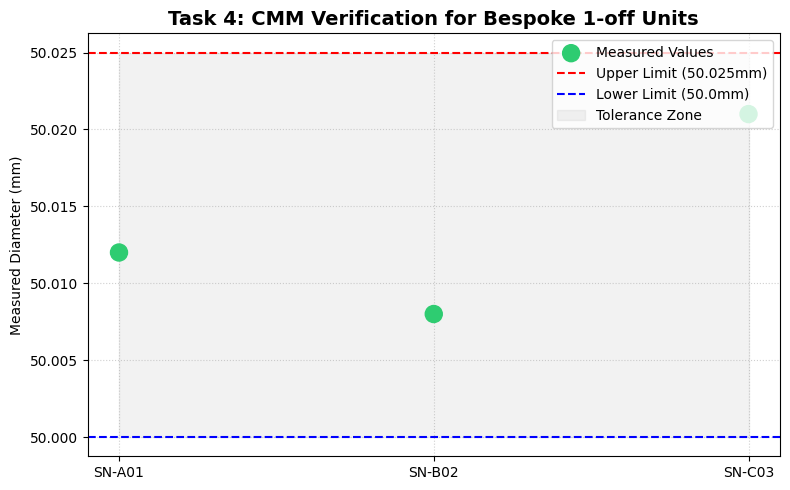

In [ ]:
import matplotlib.pyplot as plt

# Representative CMM data for unique 1-off units
serial_numbers = ['SN-A01', 'SN-B02', 'SN-C03'] # Small quantity / 1-offs
measured_values = [50.012, 50.008, 50.021] # High precision measurements

# ISO 286 Limits for 50H7
upper_limit = 50.025
lower_limit = 50.000

plt.figure(figsize=(8, 5))

# Plotting each 1-off unit
colors = ['#2ecc71' if lower_limit <= val <= upper_limit else '#e74c3c' for val in measured_values]
plt.scatter(serial_numbers, measured_values, color=colors, s=150, zorder=3, label='Measured Values')

# Limit Lines
plt.axhline(y=upper_limit, color='red', linestyle='--', label=f'Upper Limit ({upper_limit}mm)')
plt.axhline(y=lower_limit, color='blue', linestyle='--', label=f'Lower Limit ({lower_limit}mm)')
plt.fill_between(serial_numbers, lower_limit, upper_limit, color='gray', alpha=0.1, label='Tolerance Zone')

plt.title('Task 4: CMM Verification for Bespoke 1-off Units', fontsize=14, fontweight='bold')
plt.ylabel('Measured Diameter (mm)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

###  Project Management: Implementation Timeline
---

**Conceptual Overview:**
To ensure the successful delivery of the proposed metrology strategies, a structured 4-week timeline is implemented. This project management phase ensures all calibration and inspection tasks are completed within the required timeframe.

* `Key Milestones`: Integration of Air Gauging (Task 2), establishment of the Predictive Maintenance model (Task 3), and final CMM certification for bespoke units (Task 4).
* `Consistency`: The Gantt chart uses a professional blue theme to maintain visual consistency across all technical figures in the project.

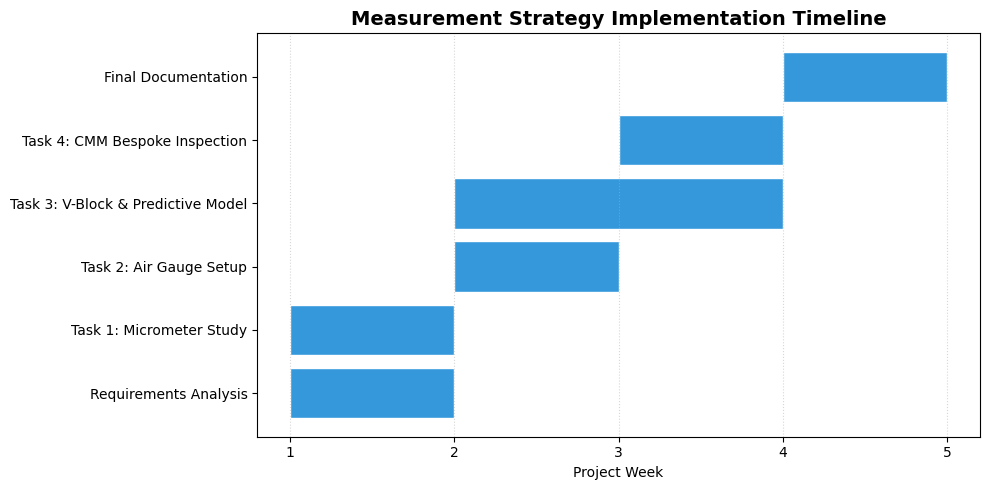

In [ ]:
import matplotlib.pyplot as plt

# Tasks and their schedules
tasks = [
    'Requirements Analysis',
    'Task 1: Micrometer Study',
    'Task 2: Air Gauge Setup',
    'Task 3: V-Block & Predictive Model',
    'Task 4: CMM Bespoke Inspection',
    'Final Documentation'
]

start_weeks = [1, 1, 2, 2, 3, 4]
durations = [1, 1, 1, 2, 1, 1]

fig, ax = plt.subplots(figsize=(10, 5))

# Using a consistent blue theme (#3498db)
for i, task in enumerate(tasks):
    ax.broken_barh([(start_weeks[i], durations[i])], (i*10, 8), facecolors='#3498db', edgecolors='white')

ax.set_yticks([i*10 + 4 for i in range(len(tasks))])
ax.set_yticklabels(tasks)
ax.set_xlabel('Project Week')
ax.set_title('Measurement Strategy Implementation Timeline', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 6))
ax.grid(True, axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()